Using GPU: Tesla T4

Polynomial degree: 1
Lambda1=0, Lambda2=0, CV RMSE=3.072423
Lambda1=0, Lambda2=4, CV RMSE=3.072275
Lambda1=0, Lambda2=8, CV RMSE=3.072130
Lambda1=0, Lambda2=12, CV RMSE=3.072002
Lambda1=0, Lambda2=16, CV RMSE=3.071889
Lambda1=0, Lambda2=20, CV RMSE=3.071779
Lambda1=4, Lambda2=0, CV RMSE=3.072214
Lambda1=4, Lambda2=4, CV RMSE=3.072081
Lambda1=4, Lambda2=8, CV RMSE=3.071965
Lambda1=4, Lambda2=12, CV RMSE=3.071858
Lambda1=4, Lambda2=16, CV RMSE=3.071760
Lambda1=4, Lambda2=20, CV RMSE=3.071677
Lambda1=8, Lambda2=0, CV RMSE=3.072083
Lambda1=8, Lambda2=4, CV RMSE=3.071969
Lambda1=8, Lambda2=8, CV RMSE=3.071864
Lambda1=8, Lambda2=12, CV RMSE=3.071768
Lambda1=8, Lambda2=16, CV RMSE=3.071681
Lambda1=8, Lambda2=20, CV RMSE=3.071600
Lambda1=12, Lambda2=0, CV RMSE=3.071981
Lambda1=12, Lambda2=4, CV RMSE=3.071877
Lambda1=12, Lambda2=8, CV RMSE=3.071781
Lambda1=12, Lambda2=12, CV RMSE=3.071694
Lambda1=12, Lambda2=16, CV RMSE=3.071616
Lambda1=12, Lambda2=20, CV RMSE=3.071543
Lamb

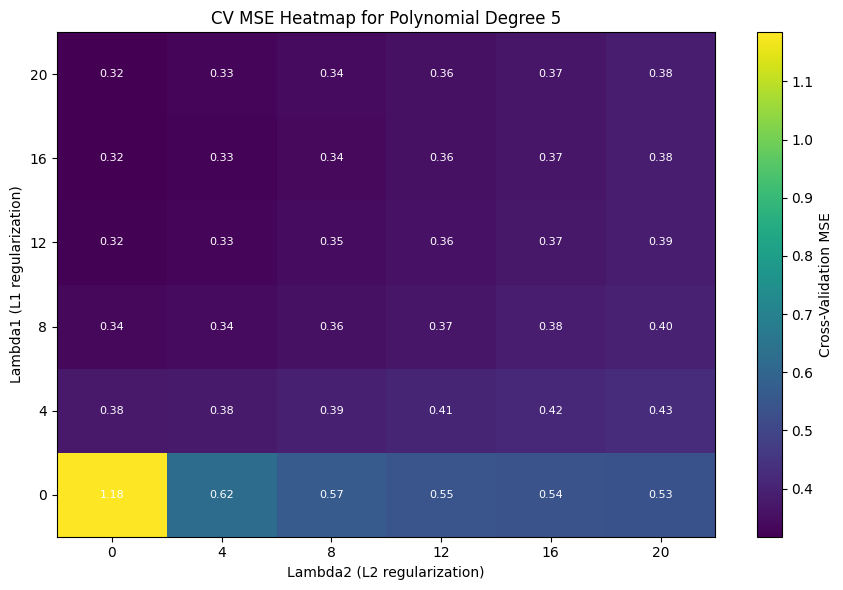

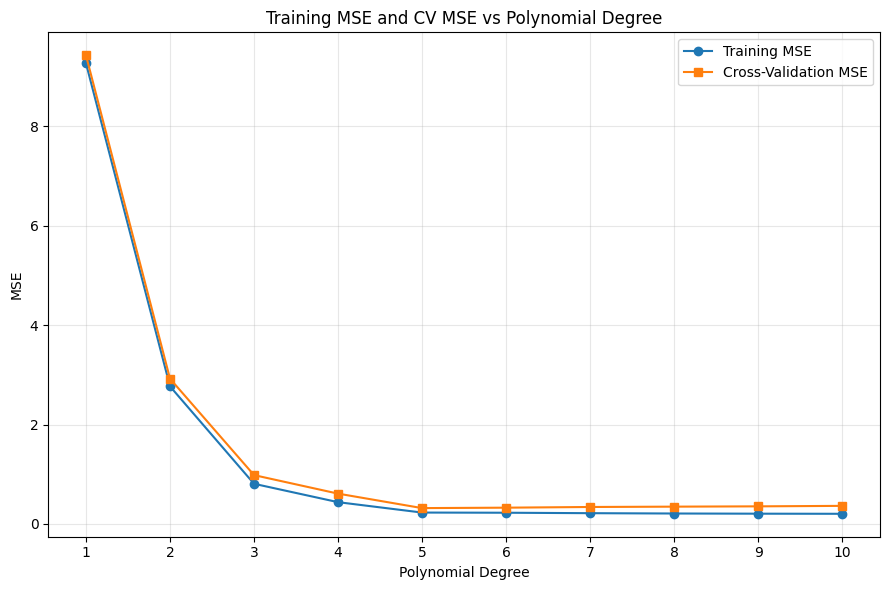


Final Model Performance
-----------------------
Training RMSE: 0.477039980430922
Training R²: 0.9775263894803622

Files saved:
- polynomial_coefficients_var1.csv
- polynomial_model_var1.pkl
- var1_elasticnet_comparison.csv
- lambda_heatmap.png
- degree_error_plot.png


In [ ]:
import pandas as pd
import numpy as np
import joblib
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score

# ------------------------------------------
# GPU setup
# ------------------------------------------

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is not available.")

device = torch.device("cuda")
dtype = torch.float64

print("Using GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------
# Load training data
# ------------------------------------------

train = pd.read_csv("BT2024031_train_var1.csv")

X = train[
    ["x1", "x2", "x3", "x4", "x5", "x6"]
].values

y = train["y"].values.reshape(-1, 1)


# ------------------------------------------
# Cross-validation and hyperparameter search
# ------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

degrees = range(1, 11)

lambda1_values = [0, 4, 8, 12, 16, 20]
lambda2_values = [0, 4, 8, 12, 16, 20]

MAX_ITER = 800
TOL = 1e-4


# ------------------------------------------
# Elastic Net using GPU-based FISTA
# ------------------------------------------

def train_model(X_train, y_train, lambda1, lambda2):
    X_train = np.asarray(X_train, dtype=np.float64)
    y_train = np.asarray(y_train, dtype=np.float64).reshape(-1, 1)

    n_samples, n_features = X_train.shape

    # Center features and target to handle the intercept separately
    x_mean = X_train.mean(axis=0, keepdims=True)
    y_mean = y_train.mean()

    X_centered = X_train - x_mean
    y_centered = y_train - y_mean

    # Transfer to GPU
    X_gpu = torch.as_tensor(
        X_centered, dtype=torch.float64, device=device
    )
    y_gpu = torch.as_tensor(
        y_centered, dtype=torch.float64, device=device
    )

    # Objective:
    # ||Xw - y||^2 + lambda1 * ||w||_1 + lambda2 * ||w||^2
    #
    # Gradient of smooth part:
    # 2 X.T @ (Xw - y) + 2 lambda2 * w

    # Lipschitz constant
    spectral_norm = torch.linalg.matrix_norm(X_gpu, ord=2).item()
    L = 2 * (spectral_norm ** 2 + lambda2)

    if L == 0:
        weights = np.zeros((n_features, 1))
        intercept = y_mean
        return weights, np.array([intercept])

    step_size = 1.0 / L

    # Initialize weights on GPU
    w = torch.zeros(
        (n_features, 1),
        dtype=torch.float64,
        device=device
    )
    z = w.clone()
    t = 1.0

    for iteration in range(MAX_ITER):
        w_old = w.clone()

        # Gradient of smooth objective
        gradient = (
            2 * X_gpu.T @ (X_gpu @ z - y_gpu)
            + 2 * lambda2 * z
        )

        # Gradient step
        v = z - step_size * gradient

        # Proximal operator for L1 penalty
        w = torch.sign(v) * torch.clamp(
            torch.abs(v) - step_size * lambda1,
            min=0.0
        )

        # FISTA acceleration
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2

        z = w + ((t - 1) / t_new) * (w - w_old)
        t = t_new

        # Convergence check
        change = torch.linalg.norm(w - w_old).item()
        old_norm = torch.linalg.norm(w_old).item()

        if change <= TOL * max(1.0, old_norm):
            break

    # Move final weights back to CPU
    weights = w.detach().cpu().numpy()

    # Recover unpenalized intercept
    intercept = y_mean - (x_mean @ weights)[0, 0]

    return weights, np.array([intercept])


# ------------------------------------------
# Prediction function
# ------------------------------------------

def predict(X, weights, intercept):
    return X @ weights + intercept


# ------------------------------------------
# Hyperparameter search with 5-fold CV
# ------------------------------------------

results = []

for degree in degrees:

    print(f"\nPolynomial degree: {degree}")

    for lambda1 in lambda1_values:
        for lambda2 in lambda2_values:

            fold_mses = []

            for train_idx, val_idx in cv.split(X):

                X_train_raw = X[train_idx]
                X_val_raw = X[val_idx]

                y_train = y[train_idx]
                y_val = y[val_idx]

                # Polynomial features
                poly = PolynomialFeatures(
                    degree=degree,
                    include_bias=False
                )

                X_train_poly = poly.fit_transform(X_train_raw)
                X_val_poly = poly.transform(X_val_raw)

                # Standardize using training fold only
                scaler = StandardScaler()

                X_train_scaled = scaler.fit_transform(X_train_poly)
                X_val_scaled = scaler.transform(X_val_poly)

                # Train Elastic Net on GPU
                weights, intercept = train_model(
                    X_train_scaled,
                    y_train,
                    lambda1,
                    lambda2
                )

                # Validation predictions
                predictions = predict(
                    X_val_scaled,
                    weights,
                    intercept
                )

                mse = np.mean((y_val - predictions) ** 2)
                fold_mses.append(mse)

            # Average validation MSE across folds
            rmse = np.sqrt(np.mean(fold_mses))

            results.append({
                "degree": degree,
                "lambda1": lambda1,
                "lambda2": lambda2,
                "rmse": rmse
            })

            print(
                f"Lambda1={lambda1}, "
                f"Lambda2={lambda2}, "
                f"CV RMSE={rmse:.6f}"
            )


# ------------------------------------------
# Find best configuration
# ------------------------------------------

results_df = pd.DataFrame(results).sort_values("rmse")

results_df.to_csv(
    "var1_elasticnet_comparison.csv",
    index=False
)

best = results_df.iloc[0]

best_degree = int(best["degree"])
best_lambda1 = float(best["lambda1"])
best_lambda2 = float(best["lambda2"])

print("\nBest Configuration")
print("------------------")
print("Degree:", best_degree)
print("Lambda1:", best_lambda1)
print("Lambda2:", best_lambda2)
print("CV RMSE:", best["rmse"])


# ------------------------------------------
# Plot 1: Heatmap of CV MSE for best degree
# ------------------------------------------

best_degree_results = results_df[
    results_df["degree"] == best_degree
].copy()

best_degree_results["mse"] = best_degree_results["rmse"] ** 2

heatmap_data = best_degree_results.pivot(
    index="lambda1",
    columns="lambda2",
    values="mse"
)

plt.figure(figsize=(9, 6))

plt.imshow(
    heatmap_data.values,
    cmap="viridis",
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Cross-Validation MSE")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)

plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.xlabel("Lambda2 (L2 regularization)")
plt.ylabel("Lambda1 (L1 regularization)")
plt.title(f"CV MSE Heatmap for Polynomial Degree {best_degree}")

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        plt.text(
            j,
            i,
            f"{heatmap_data.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white",
            fontsize=8
        )

plt.tight_layout()
plt.savefig("lambda_heatmap.png", dpi=300)
plt.show()


# ------------------------------------------
# Plot 2: Training MSE and CV MSE vs degree
# ------------------------------------------

training_mses = []
cv_mses = []
best_lambdas = []

for degree in degrees:

    degree_results = results_df[
        results_df["degree"] == degree
    ]

    best_for_degree = degree_results.loc[
        degree_results["rmse"].idxmin()
    ]

    lambda1 = float(best_for_degree["lambda1"])
    lambda2 = float(best_for_degree["lambda2"])

    best_lambdas.append((lambda1, lambda2))

    # Polynomial features on full dataset
    poly_degree = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_poly_degree = poly_degree.fit_transform(X)

    # Standardize
    scaler_degree = StandardScaler()
    X_scaled_degree = scaler_degree.fit_transform(X_poly_degree)

    # Train on full dataset using GPU
    weights_degree, intercept_degree = train_model(
        X_scaled_degree,
        y,
        lambda1,
        lambda2
    )

    # Training MSE
    train_predictions = predict(
        X_scaled_degree,
        weights_degree,
        intercept_degree
    )

    train_mse = np.mean((y - train_predictions) ** 2)
    training_mses.append(train_mse)

    # Best CV MSE for this degree
    cv_mse = best_for_degree["rmse"] ** 2
    cv_mses.append(cv_mse)


plt.figure(figsize=(9, 6))

plt.plot(
    list(degrees),
    training_mses,
    marker="o",
    label="Training MSE"
)

plt.plot(
    list(degrees),
    cv_mses,
    marker="s",
    label="Cross-Validation MSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Training MSE and CV MSE vs Polynomial Degree")
plt.xticks(list(degrees))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("degree_error_plot.png", dpi=300)
plt.show()


# ------------------------------------------
# Train final model using best configuration
# ------------------------------------------

poly = PolynomialFeatures(
    degree=best_degree,
    include_bias=False
)

X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

weights, intercept = train_model(
    X_scaled,
    y,
    best_lambda1,
    best_lambda2
)


# ------------------------------------------
# Final model performance: RMSE and R²
# ------------------------------------------

final_predictions = predict(
    X_scaled,
    weights,
    intercept
)

training_rmse = np.sqrt(
    np.mean((y - final_predictions) ** 2)
)

training_r2 = r2_score(y, final_predictions)

print("\nFinal Model Performance")
print("-----------------------")
print("Training RMSE:", training_rmse)
print("Training R²:", training_r2)


# ------------------------------------------
# Convert coefficients to original scale
# ------------------------------------------

original_coefficients = weights.flatten() / scaler.scale_

original_intercept = (
    intercept[0]
    - np.sum(
        weights.flatten() * scaler.mean_ / scaler.scale_
    )
)

feature_names = poly.get_feature_names_out(
    ["x1", "x2", "x3", "x4", "x5", "x6"]
)

coef_df = pd.DataFrame({
    "Term": ["Intercept"] + list(feature_names),
    "Coefficient": [
        original_intercept
    ] + list(original_coefficients)
})

coef_df.to_csv(
    "polynomial_coefficients_var1.csv",
    index=False
)


# ------------------------------------------
# Save model and transformations
# ------------------------------------------

joblib.dump({
    "poly": poly,
    "scaler": scaler,
    "weights": weights,
    "intercept": intercept,
    "degree": best_degree,
    "lambda1": best_lambda1,
    "lambda2": best_lambda2,
    "training_rmse": training_rmse,
    "training_r2": training_r2
}, "polynomial_model_var1.pkl")


print("\nFiles saved:")
print("- polynomial_coefficients_var1.csv")
print("- polynomial_model_var1.pkl")
print("- var1_elasticnet_comparison.csv")
print("- lambda_heatmap.png")
print("- degree_error_plot.png")

In [ ]:
import pandas as pd
import numpy as np
import joblib

# Load the saved Var 1 model
model_data = joblib.load("polynomial_model_var1.pkl")

poly = model_data["poly"]
scaler = model_data["scaler"]
weights = model_data["weights"]
intercept = model_data["intercept"]

# Load test data
test = pd.read_csv("BT2024031_test_var1.csv")

# Use all columns as features
X_test = test.values

# Apply the same transformations used during training
X_test_poly = poly.transform(X_test)
X_test_scaled = scaler.transform(X_test_poly)

# Generate predictions
predictions = (X_test_scaled @ weights + intercept).ravel()

# Save predictions
output = pd.DataFrame({
    "prediction": predictions
})

output.to_csv("var1_test_predictions.csv", index=False)

print("Predictions saved to var1_test_predictions.csv")
print(output.head())

Predictions saved to var1_test_predictions.csv
   prediction
0   -2.357655
1    2.998700
2    6.508788
3    0.022718
4   -3.727213
